## 1. Data Loading
### 1.1 Mount Drive and locate dataset
- Mount Google Drive
- List the top level of My Drive to find the dataset folder

In [3]:
from google.colab import drive
drive.mount("/content/drive")

import os
root = "/content/drive/MyDrive"
for name in sorted(os.listdir(root)):
    print(name)

Mounted at /content/drive
Colab Notebooks
data


### 1.2 Inspect folder structure
- Walk the dataset folder and count files per subfolder
- Show file extensions and a few example names with sizes

In [4]:
import os
from collections import Counter

data_dir = "/content/drive/MyDrive/data"

for root, dirs, files in os.walk(data_dir):
    depth = root.replace(data_dir, "").count(os.sep)
    exts = Counter(os.path.splitext(f)[1].lower() for f in files)
    print(f"{'  ' * depth}{os.path.basename(root)}/  files={len(files)}  exts={dict(exts)}")
    for f in sorted(files)[:3]:
        size_mb = os.path.getsize(os.path.join(root, f)) / 1e6
        print(f"{'  ' * (depth + 1)}{f}  {size_mb:.2f} MB")

data/  files=0  exts={}
  labels/  files=456  exts={'.png': 456}
    0.png  0.00 MB
    1.png  0.00 MB
    10.png  0.00 MB
  images/  files=306  exts={'.tif': 306}
    0.tif  0.39 MB
    1.tif  0.39 MB
    10.tif  0.39 MB


### 1.3 Check image and label pairing
- Extract numeric IDs from file names in both folders
- Count matched pairs, images without labels, and labels without images

In [5]:
import os

img_dir = os.path.join(data_dir, "images")
lbl_dir = os.path.join(data_dir, "labels")

img_ids = {os.path.splitext(f)[0] for f in os.listdir(img_dir)}
lbl_ids = {os.path.splitext(f)[0] for f in os.listdir(lbl_dir)}

matched = img_ids & lbl_ids
print("images:", len(img_ids))
print("labels:", len(lbl_ids))
print("matched pairs:", len(matched))
print("images without label:", len(img_ids - lbl_ids))
print("labels without image:", len(lbl_ids - img_ids))
print("sample unmatched labels:", sorted(lbl_ids - img_ids)[:10])
print("sample unmatched images:", sorted(img_ids - lbl_ids)[:10])

images: 306
labels: 456
matched pairs: 306
images without label: 0
labels without image: 150
sample unmatched labels: ['100_184', '101_89', '102_179', '103_225', '104_20', '105_148', '106_267', '107_59', '108_236', '109_223']
sample unmatched images: []


### 1.4 Copy matched pairs and inspect one sample
- Copy only the 306 matched image and label files to local disk for faster reads
- Load one image and its mask
- Print shape, dtype, and value range

In [6]:
!pip install -q tifffile imagecodecs

import shutil
import numpy as np
import tifffile
from PIL import Image

local_dir = "/content/local_data"
os.makedirs(f"{local_dir}/images", exist_ok=True)
os.makedirs(f"{local_dir}/labels", exist_ok=True)

ids = sorted(matched, key=int)
for i in ids:
    shutil.copy(f"{img_dir}/{i}.tif", f"{local_dir}/images/{i}.tif")
    shutil.copy(f"{lbl_dir}/{i}.png", f"{local_dir}/labels/{i}.png")

sample_id = ids[0]
img = tifffile.imread(f"{local_dir}/images/{sample_id}.tif")
lbl = np.array(Image.open(f"{local_dir}/labels/{sample_id}.png"))

print("sample id:", sample_id)
print("image shape:", img.shape, "dtype:", img.dtype)
print("image min/max:", img.min(), img.max())
print("label shape:", lbl.shape, "dtype:", lbl.dtype)
print("label unique values:", np.unique(lbl))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 30.8 MB/s eta 0:00:00
sample id: 0
image shape: (128, 128, 12) dtype: int16
image min/max: -28 4975
label shape: (128, 128) dtype: uint8
label unique values: [0 1]


### 1.5 Load full dataset and compute per-band statistics
- Load all 306 images and masks into arrays
- Check shapes, NaNs, and mask values across the dataset
- Compute per-band min, max, mean, std, and fraction of negative pixels
- Compute pixel-level class ratio and per-image water fraction

In [7]:
import pandas as pd

X = np.stack([tifffile.imread(f"{local_dir}/images/{i}.tif") for i in ids])
y = np.stack([np.array(Image.open(f"{local_dir}/labels/{i}.png")) for i in ids])

print("X shape:", X.shape, "dtype:", X.dtype)
print("y shape:", y.shape, "dtype:", y.dtype)
print("mask unique values:", np.unique(y))

band_names = ["Coastal", "Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2",
              "QA", "Merit DEM", "Copernicus DEM", "ESA cover", "Water occ."]

flat = X.reshape(-1, 12).astype(np.float64)
stats = pd.DataFrame({
    "min": flat.min(0),
    "max": flat.max(0),
    "mean": flat.mean(0),
    "std": flat.std(0),
    "pct_negative": (flat < 0).mean(0) * 100,
    "n_unique": [len(np.unique(X[..., c])) for c in range(12)],
}, index=band_names).round(2)
print(stats)

water_frac = y.mean(axis=(1, 2))
print("\nwater pixels:", f"{y.mean() * 100:.2f}%")
print("background pixels:", f"{(1 - y.mean()) * 100:.2f}%")
print("images with no water:", int((water_frac == 0).sum()))
print("images with over 50% water:", int((water_frac > 0.5).sum()))
print("per-image water fraction (min, median, max):",
      water_frac.min().round(3), np.median(water_frac).round(3), water_frac.max().round(3))

X shape: (306, 128, 128, 12) dtype: int16
y shape: (306, 128, 128) dtype: uint8
mask unique values: [0 1]
                   min      max     mean      std  pct_negative  n_unique
Coastal        -1393.0   6568.0   396.47   270.07          0.42      4676
Blue           -1169.0   9659.0   494.62   325.98          0.16      6612
Green           -722.0  11368.0   822.32   418.12          0.01      7090
Red             -684.0  12041.0   973.67   586.70          0.62      7333
NIR             -412.0  15841.0  2090.11  1055.98          1.36      6815
SWIR1           -335.0  15252.0  1964.05  1191.42          1.07      6356
SWIR2           -258.0  14647.0  1351.27   961.76          0.66      5256
QA                64.0    255.0   102.74    48.80          0.00        41
Merit DEM      -9999.0   4245.0   141.80  1364.98          1.55      2902
Copernicus DEM     8.0   4287.0   300.74   496.04          0.00      2875
ESA cover         10.0    100.0    35.10    20.18          0.00        10
Water 

### 1.6 Check anomalies found in the statistics
- Value counts for ESA cover and top QA values
- Count Water occurrence values above 100
- Locate Merit DEM -9999 pixels and compare with Copernicus DEM
- Percentiles of spectral bands to see how extreme the outliers are

In [8]:
print("ESA cover value counts:")
print(pd.Series(X[..., 10].ravel()).value_counts().sort_index())

print("\nQA top 10 values:")
print(pd.Series(X[..., 7].ravel()).value_counts().head(10))

occ = X[..., 11]
print("\nWater occ. values above 100:", int((occ > 100).sum()))
print(pd.Series(occ[occ > 100]).value_counts().sort_index())

merit_bad = X[..., 8] == -9999
print("\nMerit -9999 pixels:", int(merit_bad.sum()))
print("images containing them:", int(merit_bad.any(axis=(1, 2)).sum()))
print("Copernicus values at those pixels (min, max):",
      X[..., 9][merit_bad].min() if merit_bad.any() else None,
      X[..., 9][merit_bad].max() if merit_bad.any() else None)

pcts = [0.1, 1, 50, 99, 99.9]
pct_table = pd.DataFrame(
    {band_names[c]: np.percentile(X[..., c], pcts) for c in range(7)},
    index=[f"p{p}" for p in pcts]
).T.round(0)
print("\nSpectral band percentiles:")
print(pct_table)

ESA cover value counts:
10     1191684
20      112322
30     1128291
40     1839547
50      123071
60       70381
70          27
80      535069
90       10222
100       2890
Name: count, dtype: int64

QA top 10 values:
64     2539819
128     974307
96      549087
192     430317
160     208062
224     191022
80       31807
208      12559
68       11739
240      11296
Name: count, dtype: int64

Water occ. values above 100: 211
101    85
102    38
103    14
104    52
105    17
107     3
108     1
111     1
Name: count, dtype: int64

Merit -9999 pixels: 77704
images containing them: 7
Copernicus values at those pixels (min, max): 10 63

Spectral band percentiles:
          p0.1     p1     p50     p99   p99.9
Coastal  -55.0   36.0   363.0  1123.0  3679.0
Blue     -19.0   70.0   458.0  1357.0  4430.0
Green     77.0  181.0   775.0  2000.0  5095.0
Red      -63.0   27.0   904.0  2680.0  5444.0
NIR     -101.0  -28.0  2164.0  4347.0  5399.0
SWIR1    -71.0   -3.0  1987.0  4624.0  5147.0
SWIR2    -

### 1.7 Visualize all bands for one sample
- Plot the 12 bands, RGB composite, and mask for one image
- Merit -9999 pixels are hidden so they do not distort the color scale

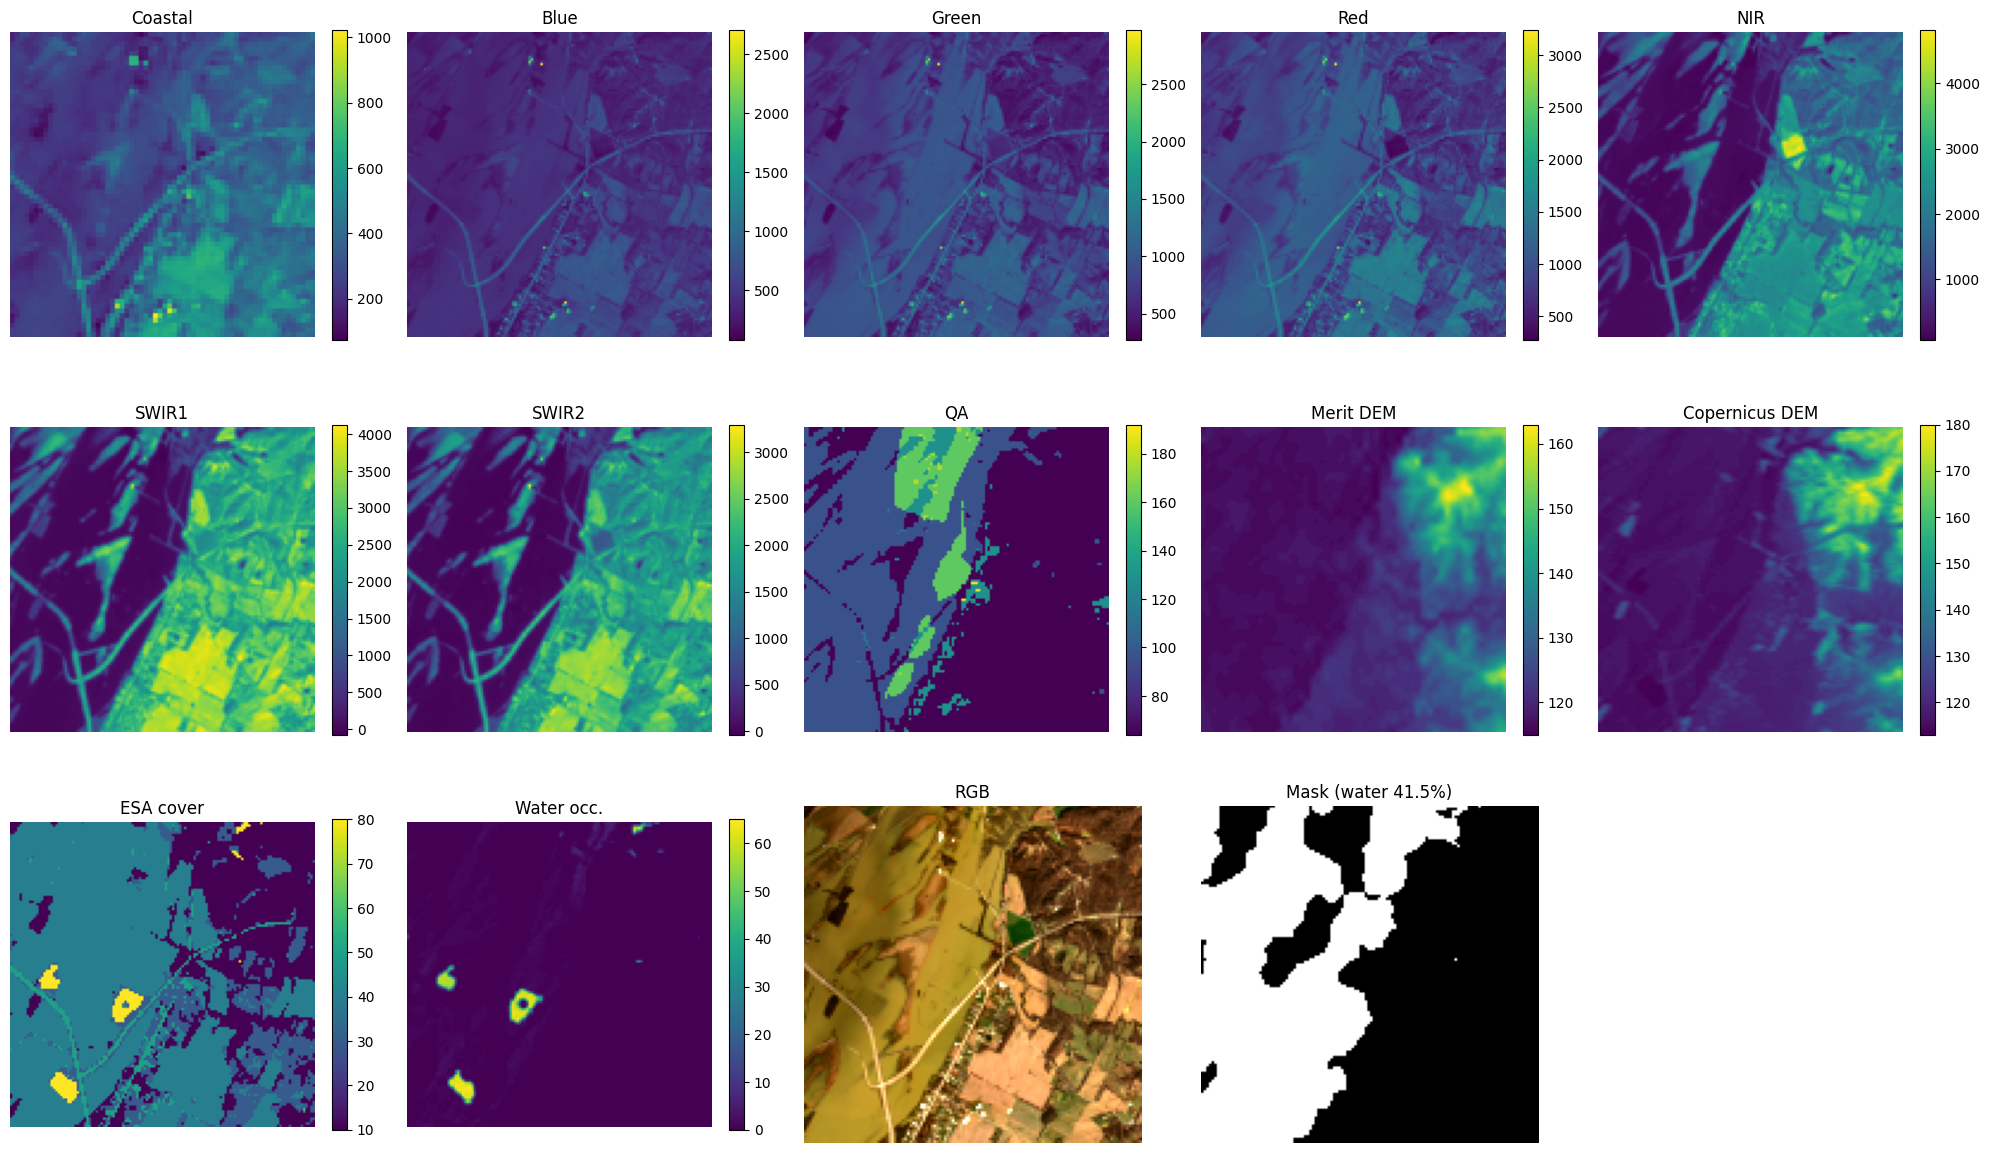

sample index: 9 id: 9


In [9]:
import matplotlib.pyplot as plt

candidates = np.where((water_frac > 0.2) & (water_frac < 0.5))[0]
idx = candidates[0]
sample = X[idx].astype(np.float32)
sample[..., 8][sample[..., 8] == -9999] = np.nan

rgb = sample[..., [3, 2, 1]]
lo, hi = np.nanpercentile(rgb, 2), np.nanpercentile(rgb, 98)
rgb = np.clip((rgb - lo) / (hi - lo), 0, 1)

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.ravel()

for c in range(12):
    im = axes[c].imshow(sample[..., c], cmap="viridis")
    axes[c].set_title(band_names[c])
    axes[c].axis("off")
    plt.colorbar(im, ax=axes[c], fraction=0.046)

axes[12].imshow(rgb)
axes[12].set_title("RGB")
axes[12].axis("off")

axes[13].imshow(y[idx], cmap="gray")
axes[13].set_title(f"Mask (water {water_frac[idx] * 100:.1f}%)")
axes[13].axis("off")

axes[14].axis("off")
plt.tight_layout()
plt.show()
print("sample index:", idx, "id:", ids[idx])

### 1.8 Band separability for water vs background
- Sample 400k pixels across the dataset
- Compute ROC AUC of each raw band and of candidate water indices (NDWI, MNDWI, AWEInsh)
- Separation score is abs(AUC - 0.5) * 2, where 1 means perfect and 0 means useless
- Direction shows whether water has lower or higher values than background

       feature  mean_water  mean_background    direction  separation
         MNDWI       0.290           -0.483 water higher       0.805
          NDWI    1670.876           -0.503 water higher       0.789
           NIR     960.069         2485.353  water lower       0.785
       AWEInsh   -1832.853       -11256.341 water higher       0.726
         SWIR1     814.872         2366.750  water lower       0.721
         SWIR2     594.542         1616.838  water lower       0.681
    Water occ.      37.122            0.271 water higher       0.618
     ESA cover      51.224           29.485 water higher       0.490
Copernicus DEM     154.352          351.654  water lower       0.402
     Merit DEM     162.511          346.837  water lower       0.393
            QA     125.836           94.778 water higher       0.393
       Coastal     362.223          407.761  water lower       0.088
         Green     825.410          819.575 water higher       0.079
           Red     948.698        

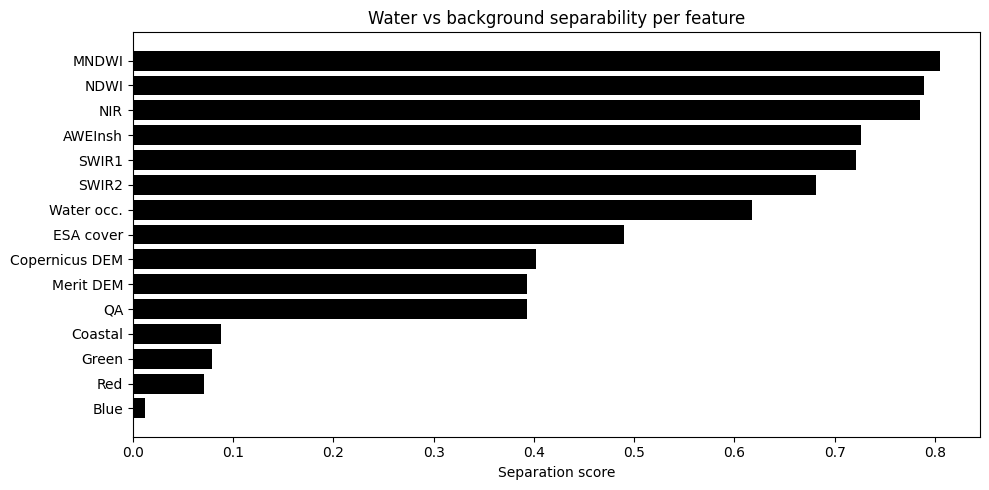

In [10]:
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(42)
n = 400000
sel = rng.choice(X.shape[0] * 128 * 128, n, replace=False)
px = X.reshape(-1, 12)[sel].astype(np.float64)
lab = y.reshape(-1)[sel]

G, NIR, SW1, SW2 = px[:, 2], px[:, 4], px[:, 5], px[:, 6]
feats = {band_names[c]: px[:, c] for c in range(12)}
feats["NDWI"] = (G - NIR) / (G + NIR + 1e-6)
feats["MNDWI"] = (G - SW1) / (G + SW1 + 1e-6)
feats["AWEInsh"] = 4 * (G - SW1) - (0.25 * NIR + 2.75 * SW2)

rows = []
for name, v in feats.items():
    valid = (v != -9999) if name == "Merit DEM" else np.ones(len(v), dtype=bool)
    v, l = v[valid], lab[valid]
    auc = roc_auc_score(l, v)
    rows.append({
        "feature": name,
        "mean_water": v[l == 1].mean(),
        "mean_background": v[l == 0].mean(),
        "direction": "water lower" if auc < 0.5 else "water higher",
        "separation": abs(auc - 0.5) * 2,
    })

sep = pd.DataFrame(rows).sort_values("separation", ascending=False).reset_index(drop=True)
print(sep.round(3).to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(sep["feature"][::-1], sep["separation"][::-1], color="black")
plt.xlabel("Separation score")
plt.title("Water vs background separability per feature")
plt.tight_layout()
plt.show()

### 1.9 Fix index statistics and visualize indices
- Recompute class statistics with the median to avoid outlier distortion
- Plot NDWI, MNDWI, and AWEInsh next to the mask for the same sample as 1.7

### 1.9a Band reference: what each channel measures and how water affects it

**Why water looks different in each band**
- Water absorbs more and more light as wavelength increases. Visible light partly penetrates it, while NIR and SWIR are almost fully absorbed, so water appears very dark there. Vegetation, soil and built-up surfaces stay brighter in NIR and SWIR.
- This is why the best single bands in the EDA are NIR and SWIR1, and why water indices compare Green (water relatively bright) with NIR or SWIR (water very dark).
- Wavelengths below are approximate band ranges for the Landsat 8/9 and Sentinel-2 harmonized bands at 30 m. [verify against the HLS user guide]

| Ch | Band | Approx. wavelength | What it measures | How water appears | EDA separation (cell 1.8) |
|---|---|---|---|---|---|
| 0 | Coastal | 0.43 to 0.45 µm | Deep blue-violet reflectance, strongly scattered by the atmosphere | Moderately bright, penetrates the water column, sensitive to haze | visible group, near 0.01 to 0.09 |
| 1 | Blue | 0.45 to 0.52 µm | Blue reflectance, absorbed by vegetation | Clear water reflects most here, but turbid or flooded water looks like land | visible group, near 0.01 to 0.09 |
| 2 | Green | 0.53 to 0.59 µm | Green reflectance, the visible peak of vegetation | Water is brighter than in NIR and SWIR, so Green is the numerator of NDWI and MNDWI | visible group, near 0.01 to 0.09 |
| 3 | Red | 0.64 to 0.68 µm | Red reflectance, absorbed by chlorophyll | Clear water absorbs red, sediment-rich water is brighter, so it is weak alone | visible group, near 0.01 to 0.09 |
| 4 | NIR | 0.85 to 0.88 µm | Near-infrared reflectance, high for healthy vegetation | Almost fully absorbed, so water is very dark | 0.785 |
| 5 | SWIR1 | 1.57 to 1.66 µm | Shortwave infrared, sensitive to moisture in soil and vegetation | Strongly absorbed, water is very dark, and less affected by suspended sediment than the visible bands | 0.721 |
| 6 | SWIR2 | 2.11 to 2.29 µm | Shortwave infrared, moisture and mineral content | Strongly absorbed, but shadows and other dark surfaces are also dark | 0.681 |
| 7 | QA | bit field, no wavelength | Per-pixel quality flags produced by the data provider's cloud and water masking | Bit 5 flags water, and alone it scores F1 0.789 (precision 92%, recall 69%) | 0.393 as a raw number |
| 8 | Merit DEM | meters | Terrain elevation (MERIT), -9999 marks missing values | Water sits in low, flat terrain, but elevation alone is weak | about 0.40 |
| 9 | Copernicus DEM | meters | Terrain elevation (Copernicus), valid everywhere | Same as Merit, and nearly identical to it, so it is used to fill Merit gaps | about 0.40 |
| 10 | ESA land cover | class codes | ESA WorldCover class per pixel, a category and not a quantity | Code 80 is permanent water bodies, and other codes (for example 40 cropland, 10 tree cover) are land | 0.490 |
| 11 | Water occurrence | 0 to 100 | Share of past observations in which the pixel was water [verify the source product] | High for permanent water, low for temporary water. The median for labeled water pixels is only 4, which suggests much labeled water is temporary or flooded land (hypothesis) | 0.618 |

**QA bits (HLS Fmask style) [verify against the HLS user guide]**
- Bit 0 cirrus, bit 1 cloud, bit 2 adjacent to cloud or shadow, bit 3 cloud shadow, bit 4 snow or ice, bit 5 water, bits 6 and 7 aerosol level.
- The EDA supports bit 5 as water: flagged pixels are mostly labeled water.

**Water indices used in the model**
- NDWI = (Green - NIR) / (Green + NIR): water is positive, vegetation and soil are negative (McFeeters, 1996).
- MNDWI = (Green - SWIR1) / (Green + SWIR1): replaces NIR with SWIR1, which separates water from built-up land better (Xu, 2006). It is the best single feature in the EDA (0.805).
- AWEInsh = 4 (Green - SWIR1) - (0.25 NIR + 2.75 SWIR2): a weighted combination designed to suppress shadow and dark surfaces (Feyisa et al., 2014). It was tested in the EDA (0.726) but is not used in the final input.

**What this means for the model input**
- Green, NIR and SWIR1 are kept with MNDWI and NDWI because they carry the water signal.
- QA bits and ESA classes are kept as flags, since they are categories and not quantities.
- Coastal, Blue, Red, SWIR2, both DEMs and Water occurrence are dropped from the engineered input because they are redundant, weak, or have missing values.

       feature  median_water  median_background
       Coastal       355.000            367.000
          Blue       472.000            448.000
         Green       834.000            751.000
           Red      1024.000            863.000
           NIR       604.000           2472.000
         SWIR1       286.000           2235.000
         SWIR2       287.000           1463.000
            QA        96.000             64.000
     Merit DEM       115.000            122.000
Copernicus DEM       114.000            123.000
     ESA cover        40.000             30.000
    Water occ.         4.000              0.000
          NDWI         0.175             -0.499
         MNDWI         0.396             -0.508
       AWEInsh       701.750         -10544.000


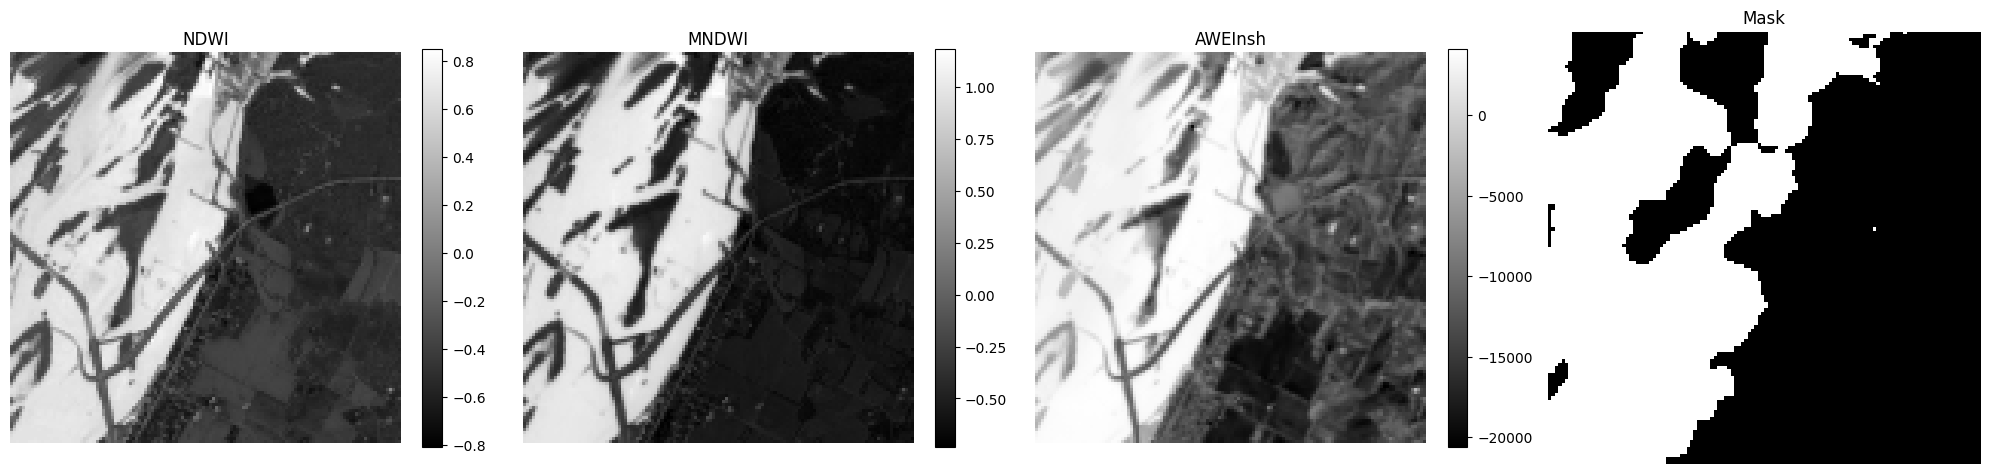

In [11]:
med = pd.DataFrame({
    "feature": list(feats.keys()),
    "median_water": [np.median(v[lab == 1][v[lab == 1] != -9999]) for v in feats.values()],
    "median_background": [np.median(v[lab == 0][v[lab == 0] != -9999]) for v in feats.values()],
}).round(3)
print(med.to_string(index=False))

def safe_ratio(a, b):
    d = a + b
    return np.where(np.abs(d) < 1e-6, np.nan, (a - b) / d)

s = sample
ndwi_img = safe_ratio(s[..., 2], s[..., 4])
mndwi_img = safe_ratio(s[..., 2], s[..., 5])
awei_img = 4 * (s[..., 2] - s[..., 5]) - (0.25 * s[..., 4] + 2.75 * s[..., 6])

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, img_, title in zip(axes[:3], [ndwi_img, mndwi_img, awei_img], ["NDWI", "MNDWI", "AWEInsh"]):
    im = ax.imshow(img_, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)
axes[3].imshow(y[idx], cmap="gray")
axes[3].set_title("Mask")
axes[3].axis("off")
plt.tight_layout()
plt.show()

### 1.10 Check water fraction distribution and varied samples
- Histogram of water fraction per image
- Show 6 samples: 2 with no water, 2 with median water, 2 with the most water
- For each: RGB, MNDWI, and mask, to spot false positives and label quality issues

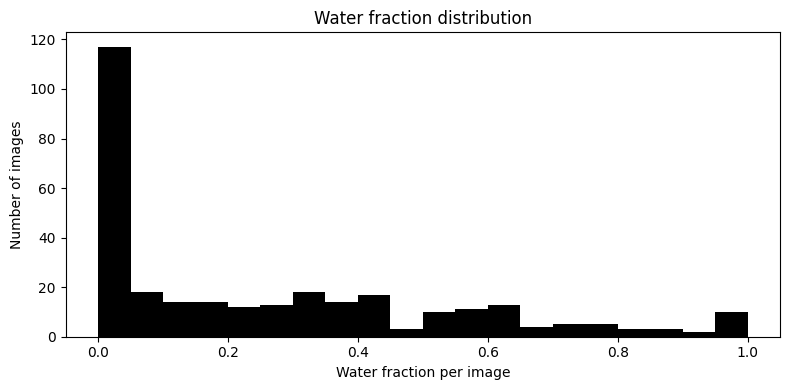

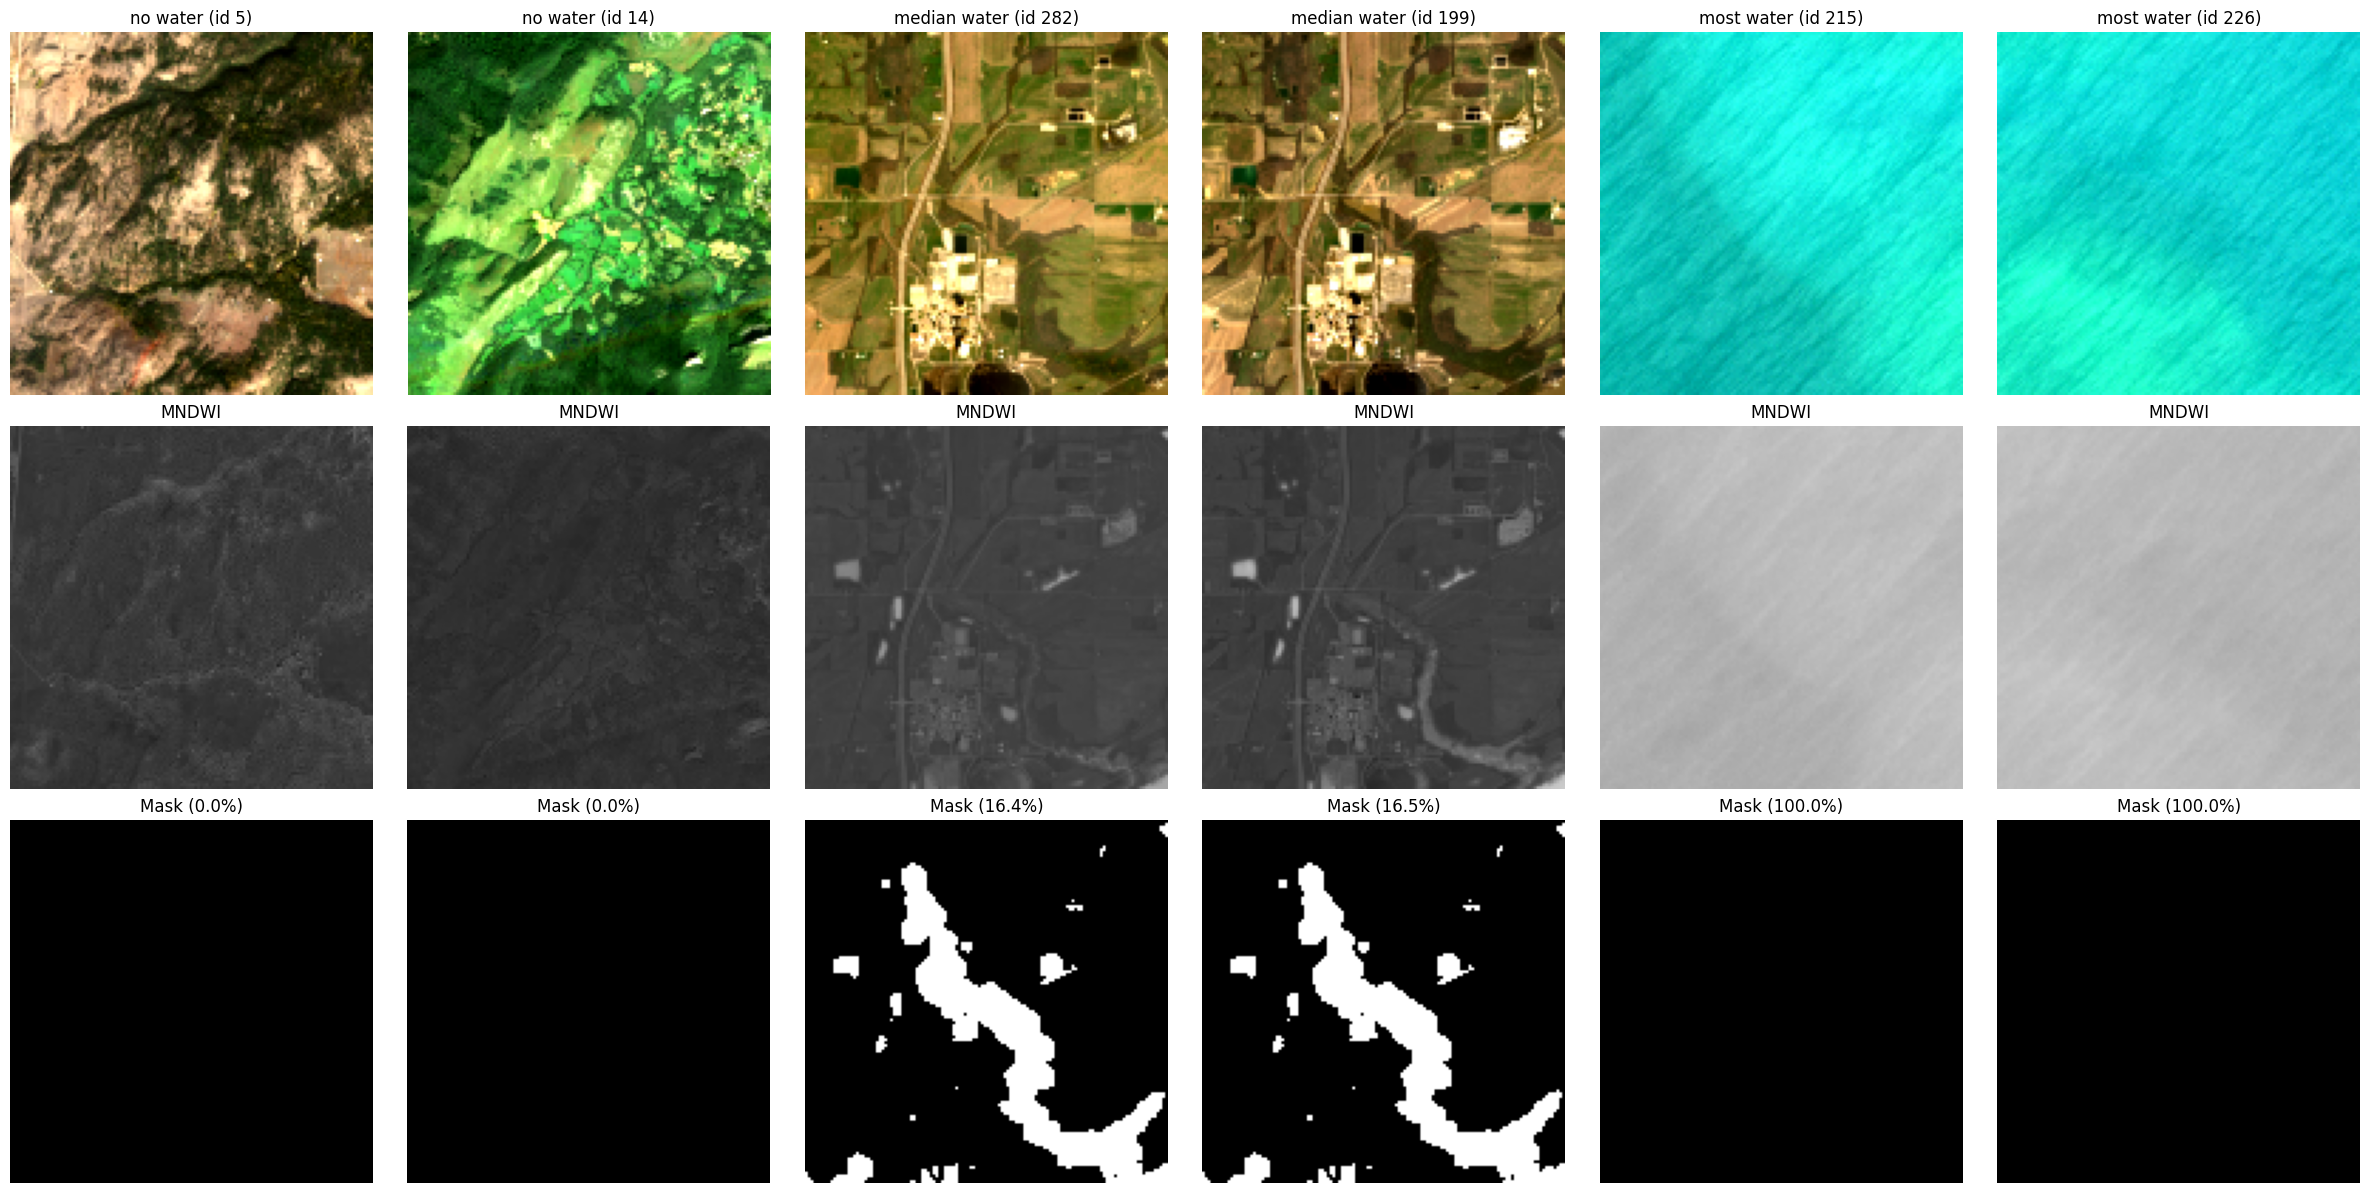

In [12]:
def to_rgb(a):
    r = a[..., [3, 2, 1]].astype(np.float32)
    lo, hi = np.percentile(r, 2), np.percentile(r, 98)
    return np.clip((r - lo) / (hi - lo + 1e-6), 0, 1)

no_water = np.where(water_frac == 0)[0][:2]
order = np.argsort(np.abs(water_frac - np.median(water_frac)))
median_water = order[:2]
most_water = np.argsort(-water_frac)[:2]
picks = list(no_water) + list(median_water) + list(most_water)
labels_ = ["no water"] * 2 + ["median water"] * 2 + ["most water"] * 2

plt.figure(figsize=(8, 4))
plt.hist(water_frac, bins=20, color="black")
plt.xlabel("Water fraction per image")
plt.ylabel("Number of images")
plt.title("Water fraction distribution")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 6, figsize=(24, 12))
for col, (i, tag) in enumerate(zip(picks, labels_)):
    a = X[i].astype(np.float32)
    mndwi_i = safe_ratio(a[..., 2], a[..., 5])
    axes[0, col].imshow(to_rgb(a))
    axes[0, col].set_title(f"{tag} (id {ids[i]})")
    axes[1, col].imshow(mndwi_i, cmap="gray", vmin=-1, vmax=1)
    axes[1, col].set_title("MNDWI")
    axes[2, col].imshow(y[i], cmap="gray")
    axes[2, col].set_title(f"Mask ({water_frac[i] * 100:.1f}%)")
    for r in range(3):
        axes[r, col].axis("off")
plt.tight_layout()
plt.show()

### 1.11 Check for near-duplicate images
- Downsample SWIR1 of every image to 16x16 and standardize it
- Compute pairwise correlation across all images
- List pairs with correlation above 0.95 and their water fractions
- Flat full-water images give unreliable correlations, so they are excluded

In [14]:
n = len(X)
small = X[..., 5].astype(np.float32).reshape(n, 16, 8, 16, 8).mean(axis=(2, 4)).reshape(n, -1)
std = small.std(axis=1)
small = (small - small.mean(axis=1, keepdims=True)) / (std[:, None] + 1e-6)
corr = small @ small.T / small.shape[1]

valid = std > 20
iu = np.triu_indices(n, 1)
mask_pairs = (corr[iu] > 0.95) & valid[iu[0]] & valid[iu[1]]
pairs = [(iu[0][k], iu[1][k], corr[iu][k]) for k in np.where(mask_pairs)[0]]
pairs.sort(key=lambda p: -p[2])

involved = set()
for i, j, _ in pairs:
    involved.update([i, j])

print("excluded flat images:", int((~valid).sum()))
print("near-duplicate pairs:", len(pairs))
print("images involved:", len(involved))
for i, j, c in pairs[:15]:
    print(f"id {ids[i]} vs id {ids[j]}  corr={c:.3f}  water={water_frac[i]:.3f} / {water_frac[j]:.3f}")

excluded flat images: 3
near-duplicate pairs: 53
images involved: 82
id 49 vs id 250  corr=1.000  water=0.314 / 0.314
id 12 vs id 263  corr=0.999  water=0.581 / 0.573
id 27 vs id 68  corr=0.999  water=0.632 / 0.632
id 126 vs id 224  corr=0.999  water=0.247 / 0.247
id 146 vs id 202  corr=0.998  water=0.987 / 0.986
id 34 vs id 237  corr=0.997  water=0.221 / 0.221
id 76 vs id 117  corr=0.997  water=0.409 / 0.407
id 56 vs id 153  corr=0.997  water=0.242 / 0.242
id 223 vs id 287  corr=0.996  water=0.325 / 0.325
id 154 vs id 221  corr=0.996  water=0.383 / 0.383
id 102 vs id 303  corr=0.996  water=0.387 / 0.388
id 16 vs id 283  corr=0.996  water=0.769 / 0.784
id 9 vs id 205  corr=0.995  water=0.415 / 0.442
id 274 vs id 290  corr=0.994  water=0.720 / 0.719
id 202 vs id 248  corr=0.993  water=0.986 / 0.987


### 1.12 Build duplicate groups and compare pairs
- Merge pairs into groups with connected components
- Count groups and effective number of unique scenes
- Check how many pairs are pixel-identical in image and mask
- Measure mask agreement per pair
- Plot the pair with the lowest mask agreement

total groups (unique scenes): 260
groups with more than 1 image: 36
group size counts: {2: 29, 3: 4, 4: 3}

pairs with identical image: 0 of 53
pairs with identical mask: 8 of 53
mask agreement (min, median): 0.95 0.994
  a   b  corr  image_identical  mean_abs_diff  mask_identical  mask_agreement
 43 158 0.974            False         88.523           False           0.950
 61 130 0.951            False        154.885           False           0.953
 61 119 0.965            False        126.646           False           0.957
124 272 0.966            False        117.543           False           0.957
102 161 0.956            False        199.130           False           0.964
161 303 0.963            False        165.106           False           0.964
100 154 0.967            False        212.155           False           0.971
100 221 0.973            False        175.810           False           0.971


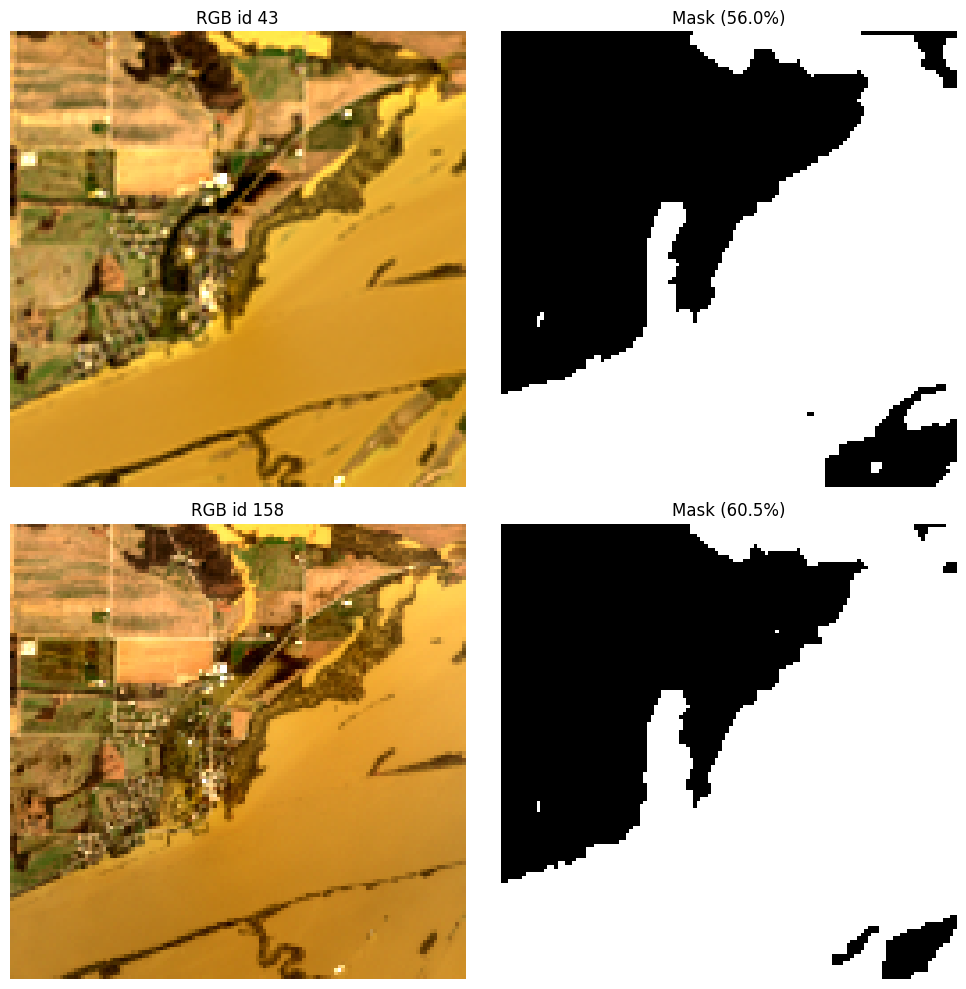

In [16]:
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

ii = np.array([p[0] for p in pairs])
jj = np.array([p[1] for p in pairs])
graph = coo_matrix((np.ones(len(pairs)), (ii, jj)), shape=(n, n))
n_groups, group = connected_components(graph, directed=False)
sizes = np.bincount(group)

print("total groups (unique scenes):", n_groups)
print("groups with more than 1 image:", int((sizes > 1).sum()))
print("group size counts:", pd.Series(sizes[sizes > 1]).value_counts().sort_index().to_dict())

rows = []
for i, j, c in pairs:
    rows.append({
        "a": ids[i], "b": ids[j], "corr": c,
        "image_identical": np.array_equal(X[i], X[j]),
        "mean_abs_diff": np.abs(X[i].astype(np.int32) - X[j].astype(np.int32)).mean(),
        "mask_identical": np.array_equal(y[i], y[j]),
        "mask_agreement": (y[i] == y[j]).mean(),
    })
pdf = pd.DataFrame(rows)
print("\npairs with identical image:", int(pdf["image_identical"].sum()), "of", len(pdf))
print("pairs with identical mask:", int(pdf["mask_identical"].sum()), "of", len(pdf))
print("mask agreement (min, median):", round(float(pdf["mask_agreement"].min()), 3), round(float(pdf["mask_agreement"].median()), 3))
print(pdf.sort_values("mask_agreement").head(8).round(3).to_string(index=False))

worst = pdf.sort_values("mask_agreement").iloc[0]
ia, ib = ids.index(worst["a"]), ids.index(worst["b"])
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for r, k in enumerate([ia, ib]):
    axes[r, 0].imshow(to_rgb(X[k]))
    axes[r, 0].set_title(f"RGB id {ids[k]}")
    axes[r, 1].imshow(y[k], cmap="gray", vmin=0, vmax=1)
    axes[r, 1].set_title(f"Mask ({water_frac[k] * 100:.1f}%)")
    axes[r, 0].axis("off")
    axes[r, 1].axis("off")
plt.tight_layout()
plt.show()

### 1.13 Check feature redundancy and categorical layers
- Correlation heatmap of the 12 channels on the sampled pixels
- Water fraction per ESA cover class
- Water fraction per QA value for the 10 most common values
- Merit -9999 pixels are treated as missing

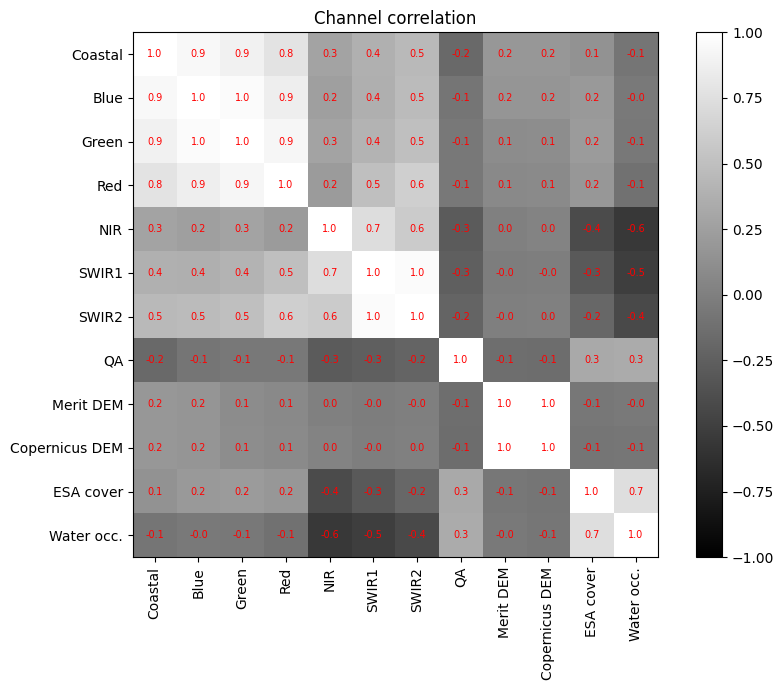

Water percentage per ESA class:
       pixels  pct_water
esa                     
10.0    95032       18.8
20.0     8943        0.1
30.0    90055        3.3
40.0   146404       26.8
50.0     9806        7.9
60.0     5611        2.9
70.0        2        0.0
80.0    43140       99.5
90.0      784       20.3
100.0     223        1.8

Water percentage per QA value (top 10):
       pixels  pct_water
qa                      
64.0   202026        8.8
68.0      964        4.3
80.0     2455       28.0
96.0    43896       93.2
128.0   78087       11.0
144.0     911       47.4
160.0   16654       90.3
192.0   34378       12.1
208.0     968       52.1
224.0   15359       92.7


In [17]:
px_c = px.copy()
px_c[px_c[:, 8] == -9999, 8] = np.nan
corr_df = pd.DataFrame(px_c, columns=band_names).corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr_df.values, cmap="gray", vmin=-1, vmax=1)
plt.xticks(range(12), band_names, rotation=90)
plt.yticks(range(12), band_names)
plt.colorbar()
plt.title("Channel correlation")
for a in range(12):
    for b in range(12):
        plt.text(b, a, f"{corr_df.values[a, b]:.1f}", ha="center", va="center", color="red", fontsize=7)
plt.tight_layout()
plt.show()

esa = pd.DataFrame({"esa": px[:, 10], "water": lab}).groupby("esa")["water"].agg(["count", "mean"])
esa["mean"] = (esa["mean"] * 100).round(1)
esa.columns = ["pixels", "pct_water"]
print("Water percentage per ESA class:")
print(esa)

qa = pd.DataFrame({"qa": px[:, 7], "water": lab})
top_qa = qa["qa"].value_counts().head(10).index
qa_tab = qa[qa["qa"].isin(top_qa)].groupby("qa")["water"].agg(["count", "mean"])
qa_tab["mean"] = (qa_tab["mean"] * 100).round(1)
qa_tab.columns = ["pixels", "pct_water"]
print("\nWater percentage per QA value (top 10):")
print(qa_tab)

### 1.14 Decode QA bits and set simple rule baselines
- For each QA bit: pixels where it is set, water rate when set, and share of all water covered
- Score simple non-learned rules on the sampled pixels: precision, recall, F1, IoU
- Gives a floor for what the U-Net must beat
- Rules use fixed thresholds, so no fitting is involved except for the QA bit chosen from this table

In [18]:
qa_int = px[:, 7].astype(int)
water = lab == 1

rows = []
for b in range(8):
    m = ((qa_int >> b) & 1) == 1
    rows.append({
        "bit": b,
        "value": 2 ** b,
        "pixels_set": int(m.sum()),
        "pct_water_if_set": round(water[m].mean() * 100, 1) if m.any() else None,
        "pct_water_if_unset": round(water[~m].mean() * 100, 1),
        "share_of_all_water": round(water[m].sum() / water.sum() * 100, 1),
    })
print(pd.DataFrame(rows).to_string(index=False))

def score(pred):
    tp = (pred & water).sum()
    fp = (pred & ~water).sum()
    fn = (~pred & water).sum()
    p = tp / (tp + fp + 1e-9)
    r = tp / (tp + fn + 1e-9)
    return {"precision": p, "recall": r, "f1": 2 * p * r / (p + r + 1e-9), "iou": tp / (tp + fp + fn + 1e-9)}

qa_water = ((qa_int >> 5) & 1) == 1
esa_water = px[:, 10] == 80
mndwi_water = feats["MNDWI"] > 0
occ_water = px[:, 11] > 50

rules = {
    "MNDWI > 0": mndwi_water,
    "QA bit 5": qa_water,
    "ESA == 80": esa_water,
    "Water occ. > 50": occ_water,
    "QA bit 5 or MNDWI > 0": qa_water | mndwi_water,
    "QA bit 5 or ESA 80 or MNDWI > 0": qa_water | esa_water | mndwi_water,
}
print(pd.DataFrame({k: score(v) for k, v in rules.items()}).T.round(3))

 bit  value  pixels_set  pct_water_if_set  pct_water_if_unset  share_of_all_water
   0      1           6             100.0                26.0                 0.0
   1      2         681               6.6                26.1                 0.0
   2      4        2325               7.2                26.1                 0.2
   3      8         471               3.0                26.1                 0.0
   4     16        6389              50.7                25.6                 3.1
   5     32       77962              92.1                10.0                69.0
   6     64      302986              26.2                25.4                76.3
   7    128      149556              29.6                23.9                42.5
                                 precision  recall     f1    iou
MNDWI > 0                            0.927   0.621  0.744  0.592
QA bit 5                             0.921   0.690  0.789  0.651
ESA == 80                            0.995   0.412  0.583  0.411
Wa

### 1.15 Check rule false positives and save metadata
- Check false positive pixels of MNDWI > 0 and QA bit 5 on the images with no water
- Save per-image metadata (id, duplicate group, water fraction, Merit missing flag)
- The preprocessing notebook can load it to build a grouped split

In [19]:
nw = np.where(water_frac == 0)[0]
rules_img = {
    "MNDWI > 0": lambda a: safe_ratio(a[..., 2], a[..., 5]) > 0,
    "QA bit 5": lambda a: ((a[..., 7].astype(int) >> 5) & 1) == 1,
}
for name, f in rules_img.items():
    fp = np.array([f(X[i].astype(np.float32)).mean() for i in nw])
    print(f"{name}: mean false positive rate {fp.mean() * 100:.2f}%, "
          f"images over 1%: {int((fp > 0.01).sum())} of {len(nw)}, worst {fp.max() * 100:.1f}%")

save_dir = "/content/drive/MyDrive/water_seg"
os.makedirs(save_dir, exist_ok=True)
meta = pd.DataFrame({
    "id": ids,
    "group": group,
    "water_frac": water_frac,
    "merit_missing": merit_bad.any(axis=(1, 2)),
})
meta.to_csv(f"{save_dir}/meta.csv", index=False)
print("saved", meta.shape, "to", save_dir)

MNDWI > 0: mean false positive rate 1.19%, images over 1%: 2 of 45, worst 49.7%
QA bit 5: mean false positive rate 0.24%, images over 1%: 2 of 45, worst 7.3%
saved (306, 4) to /content/drive/MyDrive/water_seg


### 1.16 Inspect the worst MNDWI false positive image
- Find the no-water image with the highest MNDWI false positive rate
- Plot its RGB, MNDWI, and QA bit 5

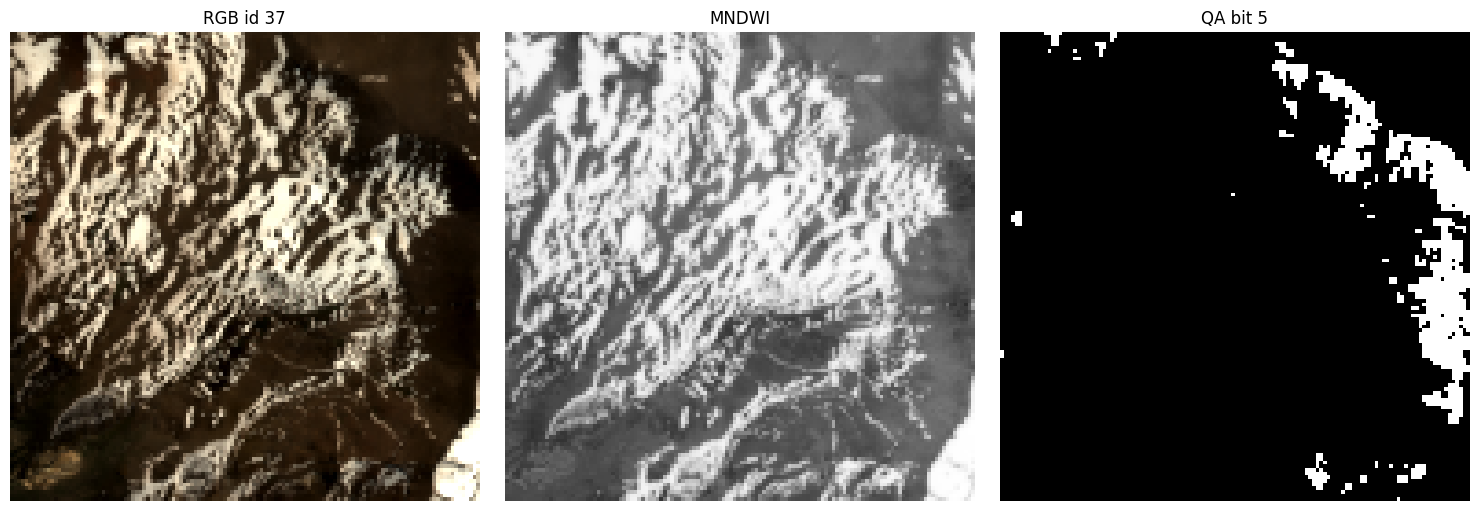

In [20]:
fp_m = np.array([
    (safe_ratio(X[i][..., 2].astype(np.float32), X[i][..., 5].astype(np.float32)) > 0).mean()
    for i in nw
])
worst_i = nw[np.argmax(fp_m)]
a = X[worst_i].astype(np.float32)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(to_rgb(a))
axes[0].set_title(f"RGB id {ids[worst_i]}")
axes[1].imshow(safe_ratio(a[..., 2], a[..., 5]), cmap="gray", vmin=-1, vmax=1)
axes[1].set_title("MNDWI")
axes[2].imshow(((a[..., 7].astype(int) >> 5) & 1), cmap="gray", vmin=0, vmax=1)
axes[2].set_title("QA bit 5")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 1.17 NDWI vs MNDWI redundancy check
- Compute both indices with a guarded denominator on the sampled pixels
- Report how many pixels the guard removes and how many values fall outside [-1, 1]
- Report Pearson and Spearman correlation between the two indices
- Compare logistic regression AUC and F1 with a grouped 5-fold split
- Feature sets: each index alone, both together, raw Green, NIR, SWIR1, and raw plus each index

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, f1_score

def guarded_ratio(a, b):
    d = a + b
    return np.where(np.abs(d) < 1e-6, np.nan, (a - b) / d)

ndwi_v = guarded_ratio(px[:, 2], px[:, 4])
mndwi_v = guarded_ratio(px[:, 2], px[:, 5])
valid = ~np.isnan(ndwi_v) & ~np.isnan(mndwi_v)

print("pixels removed by guard:", int((~valid).sum()), "of", len(valid))
print("NDWI outside [-1, 1]:", int((np.abs(ndwi_v[valid]) > 1).sum()))
print("MNDWI outside [-1, 1]:", int((np.abs(mndwi_v[valid]) > 1).sum()))

nd = np.clip(ndwi_v[valid], -1, 1)
mn = np.clip(mndwi_v[valid], -1, 1)
yy = lab[valid]
gg = group[(sel // (128 * 128))[valid]]
raw3 = px[valid][:, [2, 4, 5]]

print("Pearson:", round(float(np.corrcoef(nd, mn)[0, 1]), 3))
print("Spearman:", round(float(pd.Series(nd).corr(pd.Series(mn), method="spearman")), 3))

sets = {
    "MNDWI": np.c_[mn],
    "NDWI": np.c_[nd],
    "MNDWI + NDWI": np.c_[mn, nd],
    "Green, NIR, SWIR1": raw3,
    "Green, NIR, SWIR1 + MNDWI": np.c_[raw3, mn],
    "Green, NIR, SWIR1 + NDWI": np.c_[raw3, nd],
    "Green, NIR, SWIR1 + MNDWI + NDWI": np.c_[raw3, mn, nd],
}

gkf = GroupKFold(n_splits=5)
rows = []
for name, F in sets.items():
    aucs, f1s = [], []
    for tr, te in gkf.split(F, yy, groups=gg):
        model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
        model.fit(F[tr], yy[tr])
        p = model.predict_proba(F[te])[:, 1]
        aucs.append(roc_auc_score(yy[te], p))
        f1s.append(f1_score(yy[te], p > 0.5))
    rows.append({
        "features": name,
        "auc_mean": np.mean(aucs), "auc_std": np.std(aucs),
        "f1_mean": np.mean(f1s), "f1_std": np.std(f1s),
    })
print(pd.DataFrame(rows).round(4).to_string(index=False))

/tmp/ipykernel_1359/661980980.py:9: RuntimeWarning: divide by zero encountered in divide
  return np.where(np.abs(d) < 1e-6, np.nan, (a - b) / d)


pixels removed by guard: 1 of 400000
NDWI outside [-1, 1]: 5535
MNDWI outside [-1, 1]: 4371
Pearson: 0.892
Spearman: 0.749
                        features  auc_mean  auc_std  f1_mean  f1_std
                           MNDWI    0.9021   0.0243   0.7513  0.0441
                            NDWI    0.8954   0.0257   0.7596  0.0499
                    MNDWI + NDWI    0.9010   0.0250   0.7594  0.0484
               Green, NIR, SWIR1    0.9045   0.0242   0.7804  0.0470
       Green, NIR, SWIR1 + MNDWI    0.9085   0.0236   0.7848  0.0452
        Green, NIR, SWIR1 + NDWI    0.9126   0.0237   0.7873  0.0476
Green, NIR, SWIR1 + MNDWI + NDWI    0.9123   0.0234   0.7871  0.0472
